# University Physics with Modern Physics

<img src="..//pics/cover_ch.jpg" width=400> 





In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Chemistry\\BK_Principles_MQ_Oxtoby_8\\Appendix'

# Appendix
## Mathematics for General Chemistry
### Problems
### C.1 Using Graphs

page 1193

1. 
A particular plot of distance traveled against time elapsed
is found to be a straight line. After an elapsed time of 1.5
hours, the distance traveled was 75 miles, and after an
elapsed time of 3.0 hours, the distance traveled was 150
miles. Calculate the slope of the plot of distance against
time, and give its units.


In [ ]:
# --- Given data ---
t1 = 1.5 * u.h
t2 = 3.0 * u.h
d1 = 75 * u.imperial.mi
d2 = 150 * u.imperial.mi

# m = dy / dx = d2 - d1 / t2 - t1
m = (d2 - d1) / (t2 - t1)
print(f"slope = {m}")


slope = 50.0 mi / h


#### 2. 
The pressure of a gas in a rigid container is measured at
several different temperatures, and it is found that a plot
of pressure against temperature is a straight line. At
20.0°C the pressure is 4.30 atm, and at 100.0°C the pressure
is 5.47 atm. Calculate the slope of the plot of pressure
against temperature and give its units.

In [21]:
import astropy.units as u

# Define custom 'atm' unit
atm = u.def_unit("atm")

# --- Given data ---
temp1 = 20.0 * u.deg_C
p1 = 4.30 * atm
temp2 = 100.0 * u.deg_C
p2 = 5.47 * atm

# --- Slope calculation ---
m = (p2 - p1) / (temp2 - temp1)

# --- Clean output ---
print(f"slope = {m.value:.4f} {m.unit}")
print(f"slope = {m.value:.2e} {m.unit}")

slope = 0.0146 atm / deg_C
slope = 1.46e-02 atm / deg_C


#### 3

Rewrite each of the following linear equations in the form
y = mx + b, and give the slope and intercept of the corresponding
plot. Then draw the graph.

**(a)** y = 4x - 7

In [ ]:
def plot_linear_eq(eq_or_expr, x_var="x", y_var="y", x_range=(-5, 5)):
    """Extracts slope/intercept from a SymPy equation or expression and plots it."""
    x = sp.Symbol(x_var, real=True)

    # Handle if input is sp.Eq (y = mx + b) or just expression (mx + b)
    if isinstance(eq_or_expr, sp.Equality):
        expr = eq_or_expr.rhs
    else:
        expr = eq_or_expr

    # Extract slope (m) and y-intercept (b)
    m = expr.coeff(x)
    b = expr.subs(x, 0)

    # Calculate x-intercept (-b / m) if slope is non-zero
    x_int = -b / m if m != 0 else None

    # Print latex algebraic summary
    display(
        Math(rf"y = {sp.latex(expr)} \implies m = {sp.latex(m)},\ b = {sp.latex(b)}")
    )

    # Convert SymPy expression to executable numerical function
    f_num = sp.lambdify(x, expr, "numpy")

    # Generate points
    x_vals = np.linspace(x_range[0], x_range[1], 200)
    y_vals = f_num(x_vals)

    # Plot figure
    plt.figure(figsize=(7, 4.5))
    plt.plot(
        x_vals, y_vals, label=rf"$y = {sp.latex(expr)}$", color="blue", linewidth=2
    )

    # Reference axis lines
    plt.axhline(0, color="black", linewidth=1, linestyle="-")
    plt.axvline(0, color="black", linewidth=1, linestyle="-")

    # Plot intercepts
    plt.plot(0, float(b), "ro", label=f"$y$-intercept $(0, {b:.2f})$")
    if x_int is not None and x_range[0] <= float(x_int) <= x_range[1]:
        plt.plot(float(x_int), 0, "go", label=f"$x$-intercept $({x_int:.2f}, 0)$")

    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(rf"Plot of $y = {sp.latex(expr)}$")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

<IPython.core.display.Math object>

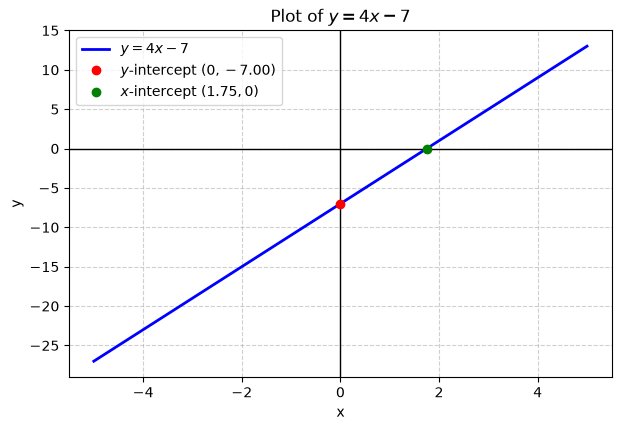

In [24]:
# Example 1: Passing sp.Eq
plot_linear_eq(sp.Eq(y, 4 * x - 7))

**(b)** 7x - 2y = 5

<IPython.core.display.Math object>

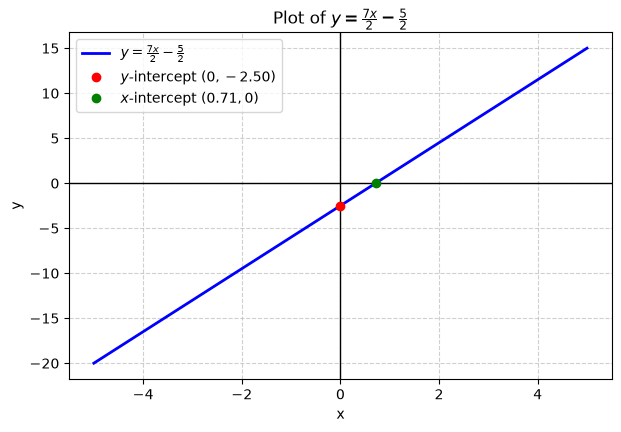

In [ ]:
eq = sp.Eq(7 * x - 2 * y, 5)
sol = sp.solve(eq, y)
plot_linear_eq(sol[0])

**(c)** 3y + 6x - 4 = 0

<IPython.core.display.Math object>

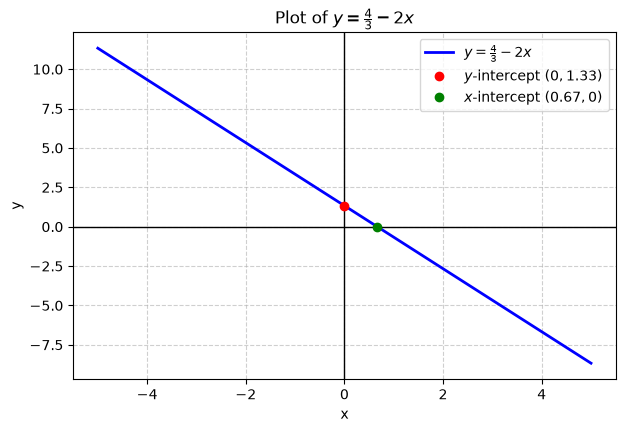

In [ ]:
eq = sp.Eq(3 * y + 6 * x - 4, 0)
sol = sp.solve(eq, y)
plot_linear_eq(sol[0])

#### 4. 
Rewrite each of the following linear equations in the form
y = mx + b, and give the slope and intercept of the corresponding
plot. Then draw the graph.

**(a)** y = -2x - 8 


<IPython.core.display.Math object>

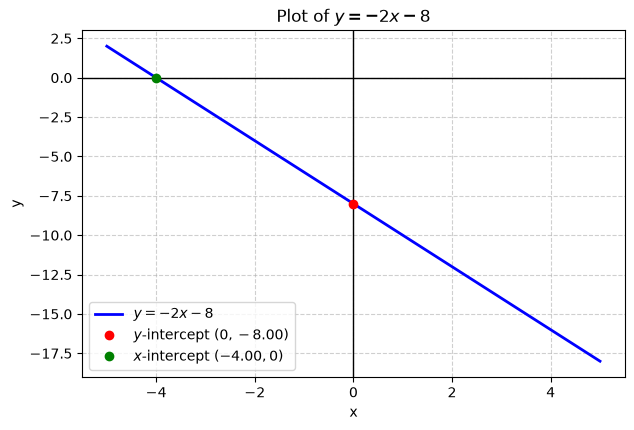

In [ ]:
plot_linear_eq(sp.Eq(y, -2 * x - 8))

**(b)** -3x + 4y = 7

<IPython.core.display.Math object>

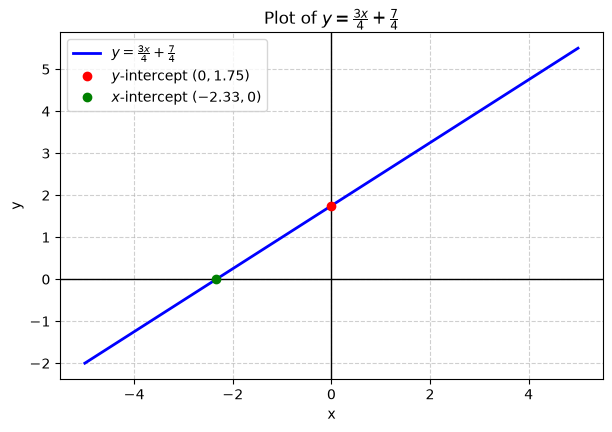

In [ ]:
eq = sp.Eq(-3 * x + 4 * y, 7)
sol = sp.solve(eq, y)
plot_linear_eq(sol[0])

**(c)** 7y - 16x + 53 = 0

<IPython.core.display.Math object>

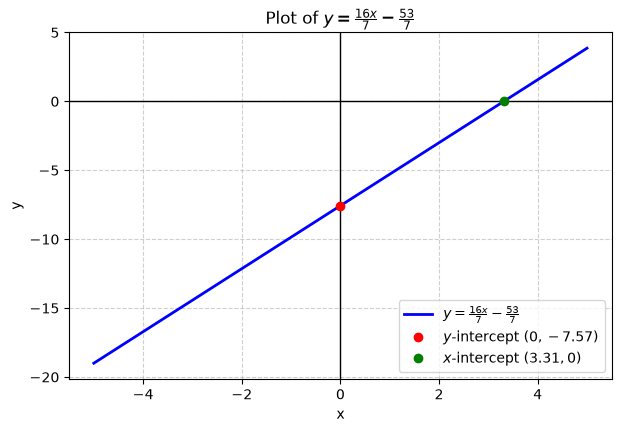

In [ ]:
eq = sp.Eq(7 * y - 16 * x + 53, 0)
sol = sp.solve(eq, y)
plot_linear_eq(sol[0])

#### 5
Graph the relation
$$y = 2x^3 - 3x^2 +6x -5$$

from y = -2 to y = +2. Is the plotted curve a straight
line?

<IPython.core.display.Math object>

<IPython.core.display.Math object>

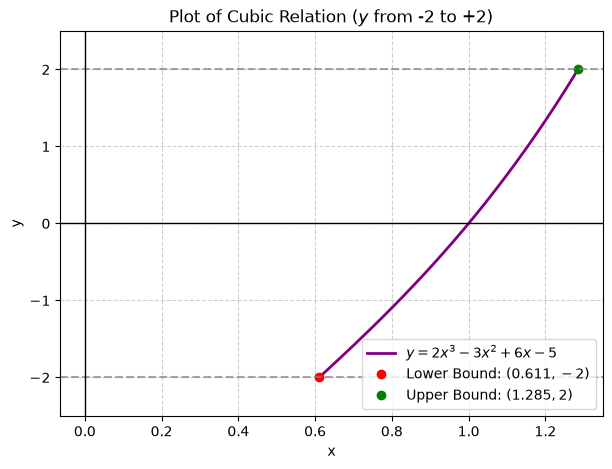

In [ ]:
# --- SymPy Symbolic Setup ---
x, y = sp.symbols("x y", real=True)
expr = 2 * x**3 - 3 * x**2 + 6 * x - 5

# Find exact x bounds for y = -2 and y = 2
x_lower_sol = sp.solve(sp.Eq(expr, -2), x)
x_upper_sol = sp.solve(sp.Eq(expr, 2), x)

# Filter for real roots
x_min = [r.evalf() for r in x_lower_sol if r.is_real][0]
x_max = [r.evalf() for r in x_upper_sol if r.is_real][0]

display(Math(rf"\text{{Cubic Relation: }} y = {sp.latex(expr)}"))
display(Math(rf"\text{{Domain for }} y \in [-2, 2]: x \in [{x_min:.4f}, {x_max:.4f}]"))

# --- Numerical Evaluation & Plotting ---
f_num = sp.lambdify(x, expr, "numpy")
x_vals = np.linspace(float(x_min), float(x_max), 300)
y_vals = f_num(x_vals)

plt.figure(figsize=(7, 5))
plt.plot(
    x_vals, y_vals, label=r"$y = 2x^3 - 3x^2 + 6x - 5$", color="purple", linewidth=2
)

# Highlight boundary points
plt.plot(float(x_min), -2, "ro", label=f"Lower Bound: $({x_min:.3f}, -2)$")
plt.plot(float(x_max), 2, "go", label=f"Upper Bound: $({x_max:.3f}, 2)$")

# Reference dashed lines for y-limits
plt.axhline(-2, color="gray", linestyle="--", alpha=0.7)
plt.axhline(2, color="gray", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.title("Plot of Cubic Relation ($y$ from -2 to +2)")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2.5, 2.5)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

#### 6

Graph the relation

$$y = \frac{8 - 10x -3x^2}{2x-3}$$

from x = -3 to x = +3. Is the plotted curve a straight
line?

<IPython.core.display.Math object>

<IPython.core.display.Math object>

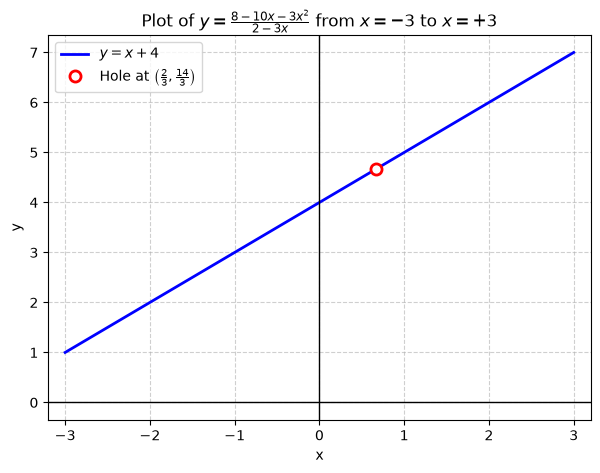

In [ ]:
# --- SymPy Symbolic Setup ---
x, y = sp.symbols("x y", real=True)
expr_raw = (8 - 10 * x - 3 * x**2) / (2 - 3 * x)

# Simplify algebraic expression
expr_simplified = sp.simplify(expr_raw)

# SymPy display blocks
display(Math(rf"\text{{Original Relation: }} y = {sp.latex(expr_raw)}"))
display(
    Math(
        rf"\text{{Simplified Relation: }} y = {sp.latex(expr_simplified)} \quad \left(x \neq \frac{{2}}{{3}}\right)"
    )
)

# --- Numerical Evaluation & Plotting ---
x_vals = np.linspace(-3, 3, 400)

# Mask the singularity at x = 2/3 to avoid division issues
hole_x = 2 / 3
hole_y = float(expr_simplified.subs(x, sp.Rational(2, 3)))

y_vals = x_vals + 4

plt.figure(figsize=(7, 5))
plt.plot(x_vals, y_vals, label=r"$y = x + 4$", color="blue", linewidth=2)

# Mark the removable discontinuity (hole)
plt.plot(
    hole_x,
    hole_y,
    "ro",
    markerfacecolor="white",
    markersize=8,
    markeredgewidth=2,
    label=r"Hole at $\left(\frac{2}{3}, \frac{14}{3}\right)$",
)

# Reference axes
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.title(r"Plot of $y = \frac{8 - 10x - 3x^2}{2 - 3x}$ from $x = -3$ to $x = +3$")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-3.2, 3.2)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()